In [33]:
import pandas as pd
import seaborn as sns

In [34]:
df = pd.read_csv('../titanic.csv', usecols=['Age', 'Fare', 'Survived'])

In [35]:
df.head()    

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [36]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [37]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:,:1], test_size=0.2, random_state=42)

In [38]:
x_train['Age_imputed'] = x_train['Age']
x_train['Age_imputed'][x_train['Age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age_imputed'].isnull().sum()).values

/tmp/ipykernel_13688/292558325.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['Age_imputed'][x_train['Age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age_imputed'].isnull().sum()).values


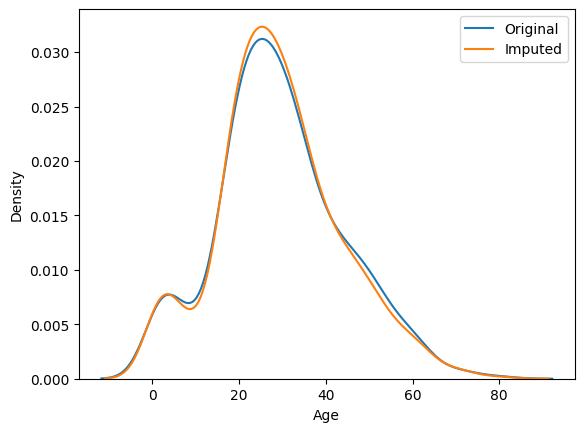

In [39]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)
sns.kdeplot(x_train['Age'], ax = ax, label = 'Original')
sns.kdeplot(x_train['Age_imputed'], ax = ax, label = 'Imputed')
ax.legend()
plt.show()

In [40]:
x_train[['Age', 'Fare', 'Age_imputed']].cov()

,Age,Fare,Age_imputed
Age,210.251707,71.580633,210.251707
Fare,71.580633,2700.831981,73.451295
Age_imputed,210.251707,73.451295,201.019729


<Axes: >

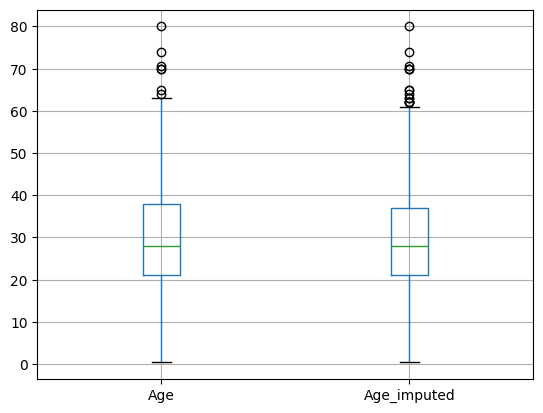

In [41]:
x_train[['Age', 'Age_imputed']].boxplot()

In [42]:
# sampled_val = x_train['Age'].dropna().sample(1, random_state = int(observation['Fare']))

## perform random imputation on categorical values

In [45]:
import requests
from io import StringIO

res = requests.get('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/house-train.csv').text
df = pd.read_csv(StringIO(res), usecols = ['GarageQual','FireplaceQu', 'SalePrice'])

In [47]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [48]:
df.isnull().sum()

FireplaceQu    690
GarageQual      81
SalePrice        0
dtype: int64

In [51]:
x = df
y = df.iloc[:,[-1]]
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size=0.2, random_state=42)

In [57]:
x_train['GarageQual_impute'] = x_train['GarageQual']
x_test['GarageQual_impute'] = x_test['GarageQual']

x_train['FireplaceQu_impute'] = x_train['FireplaceQu']
x_test['FireplaceQu_impute'] = x_test['FireplaceQu']

In [61]:
x_train['GarageQual_impute'][x_train['GarageQual_impute'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
x_test['GarageQual_impute'][x_test['GarageQual_impute'].isnull()] = x_test['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

x_train['FireplaceQu_impute'][x_train['FireplaceQu_impute'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values
x_test['FireplaceQu_impute'][x_test['FireplaceQu_impute'].isnull()] = x_test['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum()).values

/tmp/ipykernel_13688/2315408076.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['GarageQual_impute'][x_train['GarageQual_impute'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
/tmp

In [73]:
prob = pd.concat([
    x_train['GarageQual'].value_counts() / len(x_train['GarageQual'].dropna()),
    x_train['GarageQual_impute'].value_counts() / len(df)
], axis = 1)
prob.columns = ['Original', 'Imputed']

In [74]:
prob.head()

,Original,Imputed
TA,0.951087,0.760959
Fa,0.032609,0.025342
Gd,0.011775,0.009589
Ex,0.002717,0.002740
Po,0.001812,0.001370


In [75]:
prob2 = pd.concat([
    x_train['FireplaceQu'].value_counts() / len(x_train['FireplaceQu'].dropna()),
    x_train['FireplaceQu_impute'].value_counts() / len(df)
], axis = 1)
prob2.columns = ['Original', 'Imputed']

In [70]:
prob2

,Original,Imputed
Gd,0.491143,0.394521
TA,0.405797,0.325342
Fa,0.043478,0.034247
Ex,0.033816,0.026712
Po,0.025765,0.019178


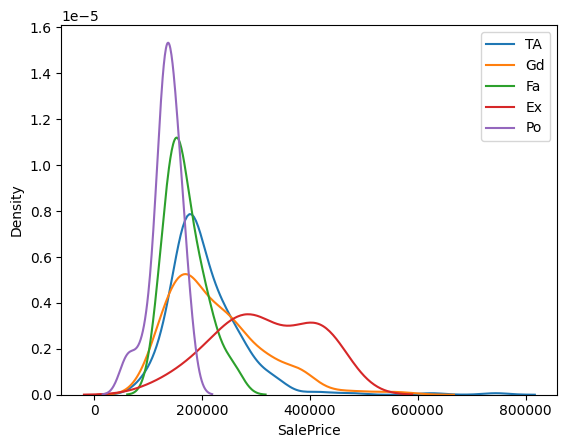

In [78]:
for category in x_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(x_train[x_train['FireplaceQu']==category]['SalePrice'], label = category)

plt.legend()
plt.show()

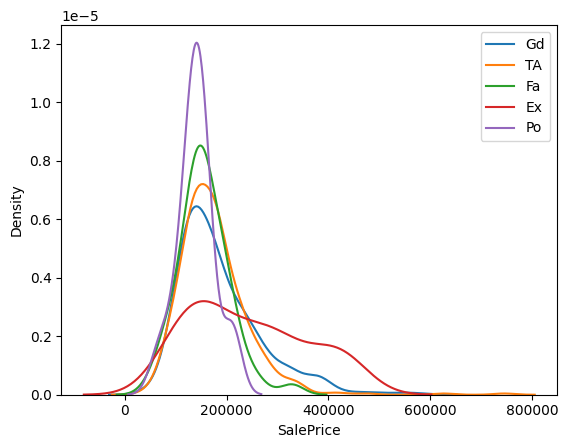

In [79]:
for category in x_train['FireplaceQu_impute'].dropna().unique():
    sns.kdeplot(x_train[x_train['FireplaceQu_impute']==category]['SalePrice'], label = category)

plt.legend()
plt.show()